In [1]:
import spacy
import pandas as pd
import spacy.lang.yo as yo
from spacy.lang.yo.stop_words import STOP_WORDS as yor_sw
from spacy.lang.en.stop_words import STOP_WORDS as en_sw
import numpy as np
import string
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import json
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import seaborn
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.utils import to_categorical
import tf2onnx
import onnx

In [2]:
nlp = spacy.blank('yo')

In [3]:
yor_df = pd.read_csv('combined_yordf.csv')
yor_df.head()

,tweet,label
0,Bae you try gan.,positive
1,Mo gbádùn rẹ.,positive
2,O ṣeun gan ni o.,positive
3,Ẹ ṣe o.,positive
4,Ìfẹ́ rẹ̀ dá mi lórí.,positive


In [4]:
yor_df.shape

(40127, 2)

In [5]:
yor_df.label.value_counts(normalize=True)

label
positive    0.366337
neutral     0.344506
negative    0.289157
Name: proportion, dtype: float64

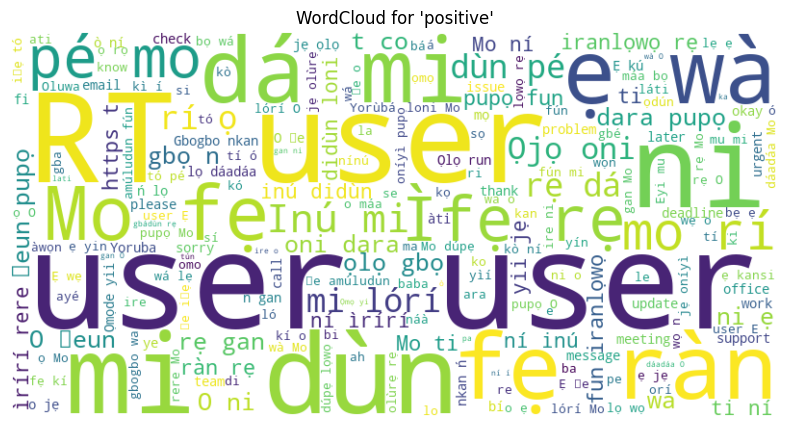

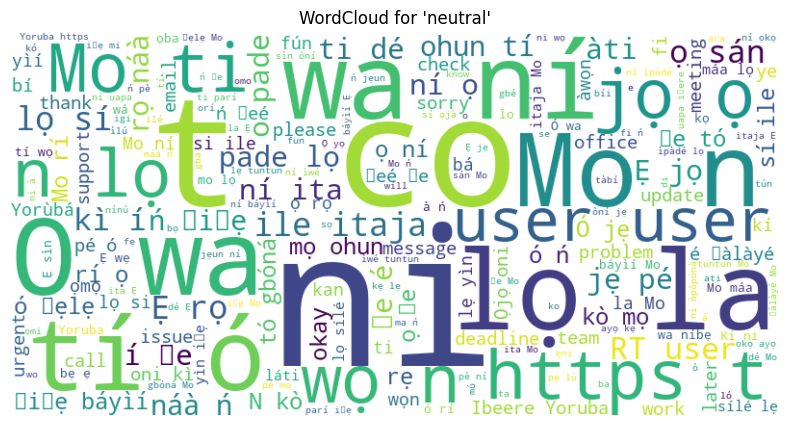

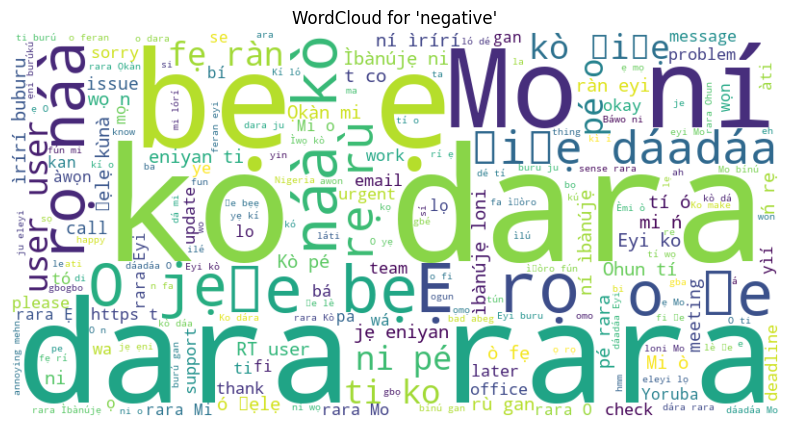

In [6]:
for label in yor_df["label"].unique():
    text = " ".join(yor_df[yor_df["label"] == label]["tweet"])
    wc = WordCloud(width=800, height=400, background_color="white").generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f"WordCloud for '{label}'")
    plt.axis("off")
    plt.show()

In [7]:
# yorsw = pd.read_csv('yor.csv')
# def preprocess_text(text):
#     if not isinstance(text, str) or not text.strip():
#         return ""
    
#     text = re.sub(r'http\S+|@\w+|#\w+|\bRT\b|"{2,}', '', text, flags=re.IGNORECASE)
#     text = re.sub(r'[.]{2,}', ' ', text)
#     text = re.sub(r'[\!\?\:\.\,]+', ' ', text)
#     text = re.sub(r'\s+', ' ', text).strip()

#     doc = nlp(text)
#     tokens = [
#         token.text.lower() for token in doc 
#         if token.text.lower() not in yorsw.word
#         and token.text not in en_sw
#         and token.text not in string.punctuation
#         and len(token.text.strip()) > 1
#         and not token.text.isdigit()
#     ]

#     return " ".join(tokens).strip() or "empty"

In [8]:
# yor_df['clean_text'] = yor_df.tweet.apply(preprocess_text)

In [9]:
# for label in yor_df["label"].unique():
#     text = " ".join(yor_df[yor_df["label"] == label]["clean_text"])
#     wc = WordCloud(width=800, height=400, background_color="white").generate(text)

#     plt.figure(figsize=(10, 5))
#     plt.imshow(wc, interpolation='bilinear')
#     plt.title(f"WordCloud for '{label}'")
#     plt.axis("off")
#     plt.show()

In [10]:
yor_df.label.value_counts()

label
positive    14700
neutral     13824
negative    11603
Name: count, dtype: int64

<Axes: ylabel='count'>

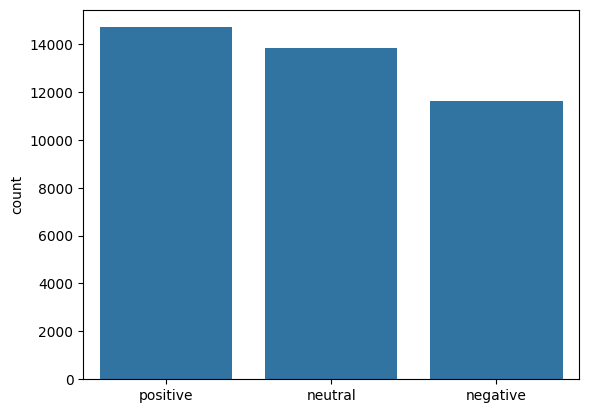

In [11]:
seaborn.countplot(x=yor_df.label.values)

In [12]:
labels = {'negative' : 0, 'neutral' : 1, 'positive' : 2}

yor_df['label'] = yor_df.label.map(labels)
yor_df.head()

,tweet,label
0,Bae you try gan.,2
1,Mo gbádùn rẹ.,2
2,O ṣeun gan ni o.,2
3,Ẹ ṣe o.,2
4,Ìfẹ́ rẹ̀ dá mi lórí.,2


In [13]:
count_positive,count_neutral,count_negative = yor_df.label.value_counts()

In [14]:
df_class_negative = yor_df[yor_df['label']== 0] 
df_class_positive = yor_df[yor_df['label']== 2]
df_class_neutral = yor_df[yor_df['label']== 1]

In [15]:
# df_class_worry_over = df_class_negative.sample(count_neutral, replace=True)
df_class_neutral_over = df_class_neutral.sample(count_positive, replace=True)
df_class_negative_over = df_class_negative.sample(count_positive, replace=True)

oversampled_data = pd.concat([df_class_neutral_over, df_class_negative_over, df_class_positive])
print(oversampled_data.label.value_counts())

label
1    14700
0    14700
2    14700
Name: count, dtype: int64


In [16]:
oversampled_data.head()

,tweet,label
1076,mo n lọ si ile itaja.,1
20142,Ẹ̀sìn òní jẹ́ pé mo lọ sí ọjà.,1
34224,"later jọ̀ọ́, work é hmm ṣàlàyé?",1
39846,Mo n lọ meeting ile itaja.,1
37501,office jẹ́ pé ó ń ṣeé ṣe.,1


- Word2vec

In [17]:
# def tokenize(text):
#     return str(text).lower().split()

# sentences = [tokenize(t) for t in oversampled_data['clean_text'].astype(str).tolist()]

# w2v_size = 100
# w2v_model = Word2Vec(
#     sentences,
#     vector_size=w2v_size,
#     window=5,
#     min_count=1,  
#     workers=4,
#     sg=1 
# )

# w2v_model.save("yoruba_word2vec.model")

In [18]:

# def sentence_vector(sentence, model, size):
#     tokens = tokenize(sentence)
#     vecs = []
#     for t in tokens:
#         if t in model.wv:
#             vecs.append(model.wv[t])
#     if len(vecs) == 0:
#         return np.zeros(size, dtype=np.float32)
#     return np.mean(vecs, axis=0)

In [19]:
# x = np.vstack([sentence_vector(t, w2v_model, w2v_size) for t in oversampled_data['clean_text'].astype(str).tolist()])
# y = oversampled_data['new_label'].astype(int).values

In [20]:
# print("X shape:", x.shape, "y shape:", y.shape)

In [21]:
# x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, stratify=y)

In [22]:
# train_df, test_df = train_test_split(oversampled_data, test_size=0.2, random_state=42, stratify=oversampled_data["label"])

In [23]:
# 1. Tokenize & pad sequences
texts = oversampled_data['tweet'].tolist()
labels = oversampled_data['label'].values

# Parameters
max_vocab_size = 10000
max_seq_length = 50  # adjust based on sentence length distribution
embedding_dim = 100
num_classes = len(np.unique(labels))

tokenizer = Tokenizer(num_words=max_vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
padded_sequences = pad_sequences(sequences, maxlen=max_seq_length, padding='post', truncating='post')

# Convert labels to one-hot
labels_cat = to_categorical(labels, num_classes=num_classes)

# Split data
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, labels_cat, test_size=0.2, random_state=42, stratify=labels)

In [24]:
tokenizer_json = tokenizer.to_json()
with open("tokenizer.json", "w", encoding="utf-8") as f:
    f.write(tokenizer_json)

In [25]:
# --- BiLSTM Model ---
def create_bilstm_model():
    model = Sequential([
        Embedding(input_dim=max_vocab_size, output_dim=embedding_dim, input_length=max_seq_length),
        Bidirectional(LSTM(64, return_sequences=False)),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# --- CNN Model ---
def create_cnn_model():
    model = Sequential([
        Embedding(input_dim=max_vocab_size, output_dim=embedding_dim, input_length=max_seq_length),
        Conv1D(filters=128, kernel_size=5, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [26]:
# Choose model to train
model = create_bilstm_model()
# Train
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {accuracy:.4f}")

c:\Users\Hp\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
427/497 ━━━━━━━━━━━━━━━━━━━━ 24s 350ms/step - accuracy: 0.6755 - loss: 0.6960

497/497 ━━━━━━━━━━━━━━━━━━━━ 343s 598ms/step - accuracy: 0.8192 - loss: 0.4361 - val_accuracy: 0.9028 - val_loss: 0.2394
Epoch 2/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 348s 618ms/step - accuracy: 0.9313 - loss: 0.1885 - val_accuracy: 0.9218 - val_loss: 0.2064
Epoch 3/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 169s 331ms/step - accuracy: 0.9579 - loss: 0.1217 - val_accuracy: 0.9289 - val_loss: 0.2169
Epoch 4/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 206s 337ms/step - accuracy: 0.9703 - loss: 0.0909 - val_accuracy: 0.9300 - val_loss: 0.2582
Epoch 5/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 169s 340ms/step - accuracy: 0.9787 - loss: 0.0642 - val_accuracy: 0.9291 - val_loss: 0.3324
Epoch 6/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 264s 532ms/step - accuracy: 0.9836 - loss: 0.0520 - val_accuracy: 0.9286 - val_loss: 0.3244
Epoch 7/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 196s 393ms/step - accuracy: 0.9869 - loss: 0.0409 - val_accuracy: 0.9280 - val_loss: 0.3507
Epoch 8/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 134s 255ms/step - accuracy: 0.9883 - loss: 0.03

In [27]:
# model2 = create_cnn_model()

# # Train
# history = model2.fit(
#     X_train, y_train,
#     epochs=10,
#     batch_size=64,
#     validation_split=0.1,
#     verbose=1
# )

# # Evaluate
# loss, accuracy = model2.evaluate(X_test, y_test)
# print(f"Test accuracy: {accuracy:.4f}")

In [28]:
# def text_to_w2v_vector(text, w2v_model):
#     words = text.split()  # or use same tokenizer/cleaning as training
#     words = [w for w in words if w in w2v_model.wv]
#     if not words:
#         return np.zeros(w2v_model.vector_size)
#     return np.mean(w2v_model.wv[words], axis=0)

# samples = [
#     "O ṣeun pupọ fun iranlọwọ rẹ.",   # Positive
#     "O jẹ eniyan ti ko dara rara.",     # Negative
#     "Mo n lọ si ile itaja.",           # Neutral
#     "Ìfẹ́ rẹ̀ dá mi lórí.",            # Positive
#     "Ìbànújẹ ni pé o ṣe bẹ́ẹ̀.",       # Negative
#     "Ọjọ́ oni dara pupọ.",           # Positive
#     "Ẹ̀rọ náà kò ṣiṣẹ́ dáadáa.",      # Negative
#     "Mo máa lọ sílé lẹ́yìn iṣẹ́.",    # Neutral
#     "Inú mi dùn pé mo rí ọ.",          # Positive
#     "O yẹ kí o dara ju eleyi lọ.",     # Negative
#     "A o pade lọ́la.",
#     "Eyi kò dáa.",
#     "O wa ní ita.",
#     "Eyi ko ye mi.",
#     "Mo fẹ́ràn rẹ gan-an.",
#     "Mi o feran eyi.",
#     "Eyi ko dara rara.",
#     "O ṣeun gan ni o.",
#     "Ọjọ́ oni dara pupọ.",
#     "Mo ti dé.",
#     "O ni ẹ̀wà.",
#     "O dara rara ni.",
#     "Kò pé rara.",
#     "Mo fe ki o maa wa.",
#     "O wa ní uapa iṣere.",

#     # ---- additional stress-test samples (20) ----
#     "Mo fẹ́ràn ẹ.",  # Short positive
#     "Kò dáa.",        # Short negative
#     "Mo ti dé.",      # Short neutral
#     "Inú mi dùn gidigidi pé mo rí ọ lónìí, o jẹ́ ẹni tí o ní inú rere ati ọwọ́ gidi.",  # Long positive
#     "Kò pé rara, ìṣe rẹ̀ ti fà ìṣòro fún gbogbo wa ati pe a nilo atunṣe lẹ́sẹ̀kẹsẹ̀.",     # Long negative
#     "Lónìí ni mo lọ sí ọjà, rà ẹran, ewa, ati ata, mo sì pada lọ sílé mi.",            # Long neutral
#     "Today was so lit! Inú mi dùn púpọ̀ gan-an.",                                       # Code-switch positive
#     "That movie no make sense rara, kò dáa lójú mi.",                                   # Code-switch negative
#     "Mo wà ni office right now, lásìkò ìsinmi.",                                       # Code-switch neutral
#     "Ó ṣeé ṣe kó dáa ju béẹ lọ, ṣùgbọ́n a máa gba béẹ ni.",                             # Sarcastic-ish / ambiguous
#     "Wow, ìyẹn dáa gan… *smh*.",                                                         # Sarcastic negative
#     "Ṣé ìwọ máa wà níbi iṣẹ́ lọ́la?",                                                   # Question neutral
#     "Mo fẹ́ràn rẹ gan-an! 😍🔥",                                                         # Positive w/ emojis
#     "Kò dáa rara ooo!!! 😡💔",                                                           # Negative w/ emojis
#     "Mo wà ní ilé oooo 😂😂",                                                            # Neutral w/ emojis
#     "Ní ọ̀sẹ̀ tó kọjá, mo lọ sí ìpàdé àtàwọn ọ̀rẹ́ mi, a jẹun, a rẹ́rìn-ín, gbogbo ẹ̀ dá mi lórí.",  # Story positive
#     "Mo gbìmọ̀ sí iṣẹ́ tuntun, ṣùgbọ́n ohun gbogbo baje lẹ́yìn ọjọ́ méjì, kò ní ìtọ́nisọ́nà kankan.", # Story negative
#     "Ní òwúrọ̀, mo jí, mo ṣe àdúrà, mo jẹun, mo sì lọ sí iṣẹ́.",                                  # Story neutral
#     "This vibe sweet die, ìgbádùn gan ni!",                                                  # Code-switch slang positive
#     "Na wah o, ìrìnàjò yìí tire mehn, kò dáa kankan."                                          # Code-switch slang negative
# ]

# # models = {
# #     "RandomForest": ran_model,
# #     "MLP": mlp_model,
# #     "XGBoost": xgb_model
# # }

# label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}

# def dl_predict(model, texts):
#     seqs = tokenizer.texts_to_sequences(texts)
#     padded = tf.keras.preprocessing.sequence.pad_sequences(
#         seqs, maxlen=max_seq_length, padding='post', truncating='post'
#     )
#     preds = model.predict(padded, verbose=0)
#     classes = np.argmax(preds, axis=1)
#     return [label_map[c] for c in classes]

# for text in samples:
#     print(f"\n{text}")

#     # ML model predictions (Word2Vec embeddings)
#     # vec = text_to_w2v_vector(text, w2v_model).reshape(1, -1)
#     # for name, clf in models.items():
#     #     pred_idx = clf.predict(vec)[0]
#     #     pred_label = label_map.get(pred_idx, pred_idx)
#     #     print(f"  {name} -> {pred_label}")

#     # DL model predictions
#     for name, dl_model in [("BiLSTM", model), ("CNN", model2)]:
#         pred_label = dl_predict(dl_model, [text])[0]
#         print(f"  {name} -> {pred_label}")

In [29]:
# samps = [
#     "O ṣeun pupọ fun iranlọwọ rẹ.",   # Positive
#     "O jẹ eniyan ti ko dara rara.",     # Negative
#     "Mo n lọ si ile itaja.",           # Neutral
#     "Ìfẹ́ rẹ̀ dá mi lórí.",            # Positive
#     "Ìbànújẹ ni pé o ṣe bẹ́ẹ̀.",       # Negative
#     "Ọjọ́ oni dara pupọ.",           # Positive
#     "Ẹ̀rọ náà kò ṣiṣẹ́ dáadáa.",      # Negative
#     "Mo máa lọ sílé lẹ́yìn iṣẹ́.",    # Neutral
#     "Inú mi dùn pé mo rí ọ.",          # Positive
#     "O yẹ kí o dara ju eleyi lọ.",     # Negative
#     "A o pade lọ́la.",
#     "Eyi kò dáa.",
#     "O wa ní ita.",
#     "Eyi ko ye mi.",
#     "Mo fẹ́ràn rẹ gan-an.",
#     "Mi o feran eyi.",
#     "Eyi ko dara rara.",
#     "O ṣeun gan ni o.",
#     "Ọjọ́ oni dara pupọ.",
#     "Mo ti dé.",
#     "O ni ẹ̀wà.",
#     "O dara rara ni.",
#     "Kò pé rara.",
#     "Mo fe ki o maa wa.",
#     "O wa ní uapa iṣere.",

#     # ---- additional stress-test samples (20) ----
#     "Mo fẹ́ràn ẹ.",  # Short positive
#     "Kò dáa.",        # Short negative
#     "Mo ti dé.",      # Short neutral
#     "Inú mi dùn gidigidi pé mo rí ọ lónìí, o jẹ́ ẹni tí o ní inú rere ati ọwọ́ gidi.",  # Long positive
#     "Kò pé rara, ìṣe rẹ̀ ti fà ìṣòro fún gbogbo wa ati pe a nilo atunṣe lẹ́sẹ̀kẹsẹ̀.",     # Long negative
#     "Lónìí ni mo lọ sí ọjà, rà ẹran, ewa, ati ata, mo sì pada lọ sílé mi.",            # Long neutral
#     "Today was so lit! Inú mi dùn púpọ̀ gan-an.",                                       # Code-switch positive
#     "That movie no make sense rara, kò dáa lójú mi.",                                   # Code-switch negative
#     "Mo wà ni office right now, lásìkò ìsinmi.",                                       # Code-switch neutral
#     "Ó ṣeé ṣe kó dáa ju béẹ lọ, ṣùgbọ́n a máa gba béẹ ni.",                             # Sarcastic-ish / ambiguous
#     "Wow, ìyẹn dáa gan… *smh*.",                                                         # Sarcastic negative
#     "Ṣé ìwọ máa wà níbi iṣẹ́ lọ́la?",                                                   # Question neutral
#     "Mo fẹ́ràn rẹ gan-an! 😍🔥",                                                         # Positive w/ emojis
#     "Kò dáa rara ooo!!! 😡💔",                                                           # Negative w/ emojis
#     "Mo wà ní ilé oooo 😂😂",                                                            # Neutral w/ emojis
#     "Ní ọ̀sẹ̀ tó kọjá, mo lọ sí ìpàdé àtàwọn ọ̀rẹ́ mi, a jẹun, a rẹ́rìn-ín, gbogbo ẹ̀ dá mi lórí.",  # Story positive
#     "Mo gbìmọ̀ sí iṣẹ́ tuntun, ṣùgbọ́n ohun gbogbo baje lẹ́yìn ọjọ́ méjì, kò ní ìtọ́nisọ́nà kankan.", # Story negative
#     "Ní òwúrọ̀, mo jí, mo ṣe àdúrà, mo jẹun, mo sì lọ sí iṣẹ́.",                                  # Story neutral
#     "This vibe sweet die, ìgbádùn gan ni!",                                                  # Code-switch slang positive
#     "Na wah o, ìrìnàjò yìí tire mehn, kò dáa kankan."                                          # Code-switch slang negative
# ]
# predss = classifier(samps)
# print(predss)

In [39]:
model.save("yoruba.keras")  # Keep Keras format
tf.saved_model.save(model, "saved_model_yoruba")  # Add SavedModel format

INFO:tensorflow:Assets written to: saved_model_yoruba\assets


INFO:tensorflow:Assets written to: saved_model_yoruba\assets
